In [5]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [6]:
import glob
import xarray as xr
PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/*"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]


File 0: /Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/station_1.nc
<xarray.Dataset>
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 ...
  * valid_time           (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-3...
    latitude             float64 ...
    longitude            float64 ...
    station_latitude     float64 ...
    station_longitude    float64 ...
    year                 (valid_time) int64 ...
Data variables: (12/15)
    u10                  (valid_time) float32 ...
    v10                  (valid_time) float32 ...
    d2m                  (valid_time) float32 ...
    t2m                  (valid_time) float32 ...
    msl                  (valid_time) float32 ...
    sst                  (valid_time) float32 ...
    ...                   ...
    mwp                  (valid_time) float32 ...
    swh                  (valid_time) float32 ...
    sea_level            (valid_time) float32 ...
    tide                 (vali

In [7]:
ds = xr.concat(datasets, dim='station')

In [8]:
ds

<xarray.Dataset>
Dimensions:              (station: 295, valid_time: 750192)
Coordinates:
  * station              (station) int64 1 10 102 103 104 108 ... 94 95 96 97 99
  * valid_time           (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-3...
    latitude             float64 48.38
    longitude            float64 -4.495
    station_latitude     (station) float64 48.38 45.57 50.1 ... 49.18 49.48
    station_longitude    (station) float64 -4.495 -1.062 ... -2.117 0.1146
    year                 (valid_time) int64 1940 1940 1940 ... 2025 2025 2025
Data variables: (12/15)
    u10                  (station, valid_time) float32 -4.661 -4.882 ... 5.358
    v10                  (station, valid_time) float32 7.723 7.483 ... 1.459
    d2m                  (station, valid_time) float32 277.2 277.0 ... 289.0
    t2m                  (station, valid_time) float32 280.1 279.8 ... 290.9
    msl                  (station, valid_time) float32 1.014e+05 ... 1.02e+05
    sst                  (station, valid_time) float32 283.5 283.5 ... 292.2
    ...                   ...
    mwp                  (station, valid_time) float32 nan nan ... 3.339 3.357
    swh                  (station, valid_time) float32 nan nan ... 0.4069 0.4357
    sea_level            (station, valid_time) float32 nan nan nan ... nan nan
    tide                 (station, valid_time) float64 -1.239 -2.089 ... 0.7854
    residual             (station, valid_time) float32 nan nan nan ... nan nan
    residual_is_deviant  (station, valid_time) int8 0 0 0 0 0 0 ... 0 0 0 0 0 0
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr

def infer_time_dim(ds: xr.Dataset, station_dim="station"):
    # Prefer common names; otherwise pick first non-station dimension that looks like datetime
    for cand in ["time", "valid_time", "date", "datetime"]:
        if cand in ds.dims or cand in ds.coords:
            return cand
    # try any coord with datetime dtype
    for c in ds.coords:
        if np.issubdtype(ds[c].dtype, np.datetime64):
            return c
    # fallback: first dim other than station
    dims = [d for d in ds.dims if d != station_dim]
    if not dims:
        raise ValueError("Could not infer a time dimension.")
    return dims[0]

def numeric_vars(ds: xr.Dataset):
    out = []
    for v in ds.data_vars:
        if np.issubdtype(ds[v].dtype, np.number):
            out.append(v)
    return out

def build_station_stats_df(ds: xr.Dataset, station_dim="station") -> pd.DataFrame:
    tdim = infer_time_dim(ds, station_dim=station_dim)
    vars_num = numeric_vars(ds)
    if not vars_num:
        raise ValueError("No numeric variables found in ds.data_vars.")

    # station index
    station_vals = ds[station_dim].values
    df = pd.DataFrame({station_dim: station_vals}).set_index(station_dim)

    for v in vars_num:
        da = ds[v]

        # Skip variables that don't have both station and time dims
        if station_dim not in da.dims or tdim not in da.dims:
            continue

        # Basic valid-mask
        valid = xr.where(np.isfinite(da), 1.0, np.nan)

        # ---- overall stats across time (per station) ----
        mean_ = da.mean(dim=tdim, skipna=True)
        std_  = da.std(dim=tdim, skipna=True)
        min_  = da.min(dim=tdim, skipna=True)
        max_  = da.max(dim=tdim, skipna=True)
        med_  = da.median(dim=tdim, skipna=True)
        q05_  = da.quantile(0.05, dim=tdim, skipna=True)
        q95_  = da.quantile(0.95, dim=tdim, skipna=True)

        count_ = xr.where(np.isfinite(da), 1, 0).sum(dim=tdim)
        n_total = da.sizes[tdim]
        frac_missing_ = 1.0 - (count_ / float(n_total))

        # ---- annual block stats (per station) ----
        # Annual max series, then summarize that series
        ann_max = da.resample({tdim: "YS"}).max(skipna=True)
        ann_mean = da.resample({tdim: "YS"}).mean(skipna=True)

        # summarize annual-max series
        annmax_mean = ann_max.mean(dim=tdim, skipna=True)
        annmax_std  = ann_max.std(dim=tdim, skipna=True)
        annmax_min  = ann_max.min(dim=tdim, skipna=True)
        annmax_max  = ann_max.max(dim=tdim, skipna=True)

        # summarize annual-mean series
        annmean_mean = ann_mean.mean(dim=tdim, skipna=True)
        annmean_std  = ann_mean.std(dim=tdim, skipna=True)
        annmean_min  = ann_mean.min(dim=tdim, skipna=True)
        annmean_max  = ann_mean.max(dim=tdim, skipna=True)

        # Add columns (flatten quantile coord if present)
        def _to_series(x):
            # quantile returns a DataArray with 'quantile' coord; squeeze it
            if "quantile" in x.dims:
                x = x.squeeze("quantile", drop=True)
            return x.to_series()

        df[f"{v}__mean"] = _to_series(mean_)
        df[f"{v}__std"] = _to_series(std_)
        df[f"{v}__min"] = _to_series(min_)
        df[f"{v}__max"] = _to_series(max_)
        df[f"{v}__median"] = _to_series(med_)
        df[f"{v}__q05"] = _to_series(q05_)
        df[f"{v}__q95"] = _to_series(q95_)
        df[f"{v}__count"] = _to_series(count_).astype("Int64")
        df[f"{v}__missing_frac"] = _to_series(frac_missing_)

        df[f"{v}__annmax_mean"] = _to_series(annmax_mean)
        df[f"{v}__annmax_std"]  = _to_series(annmax_std)
        df[f"{v}__annmax_min"]  = _to_series(annmax_min)
        df[f"{v}__annmax_max"]  = _to_series(annmax_max)

        df[f"{v}__annmean_mean"] = _to_series(annmean_mean)
        df[f"{v}__annmean_std"]  = _to_series(annmean_std)
        df[f"{v}__annmean_min"]  = _to_series(annmean_min)
        df[f"{v}__annmean_max"]  = _to_series(annmean_max)

    return df.reset_index()

# ---- run ----
stats_df = build_station_stats_df(ds, station_dim="station")
stats_df.head()

In [ ]:
stats_df.to_csv("station_variable_statistics.csv", index=False)


In [ ]:
# Variable group definitions
WEATHER_VARS = ["u10", "v10", "d2m", "t2m", "sst", "tp"]
WAVE_VARS    = ["msl", "mwd", "mwp", "swh"]

In [ ]:
def select_group_columns(stats_df, var_list):
    cols = []
    for v in var_list:
        cols.extend([c for c in stats_df.columns if c.startswith(f"{v}__")])
    return cols


In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

def cluster_group(stats_df, group_cols, k_range=range(2, 9), random_state=0):
    # 1) Select columns and coerce to numeric
    Xdf = stats_df.loc[:, group_cols].apply(pd.to_numeric, errors="coerce")

    # 2) Drop columns that are entirely NaN (common for annual stats if short records)
    Xdf = Xdf.dropna(axis=1, how="all")
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric columns found for this group after coercion.")

    # 3) Force a real float array (prevents object dtype causing isfinite failure)
    X = Xdf.to_numpy(dtype=float)

    # 4) Keep only rows that are fully finite
    mask = np.isfinite(X).all(axis=1)
    Xc = X[mask]
    if Xc.shape[0] < 3:
        raise ValueError("Not enough valid stations (rows) after dropping NaNs/infs.")

    # 5) Standardize
    scaler = StandardScaler()
    Xs = scaler.fit_transform(Xc)

    # 6) Silhouette scan
    sil_scores = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = km.fit_predict(Xs)
        sil_scores[k] = silhouette_score(Xs, labels)

    best_k = max(sil_scores, key=sil_scores.get)

    # 7) Final fit with best k
    km = KMeans(n_clusters=best_k, random_state=random_state, n_init="auto")
    labels_final = km.fit_predict(Xs)

    # 8) Map labels back to original df length
    out = np.full(len(stats_df), np.nan)
    out[mask] = labels_final

    return out, best_k, sil_scores, Xdf.columns.tolist()


In [ ]:
weather_cols = select_group_columns(stats_df, WEATHER_VARS)
stats_df["cluster_weather"], k_weather, sil_weather, used_weather_cols = cluster_group(stats_df, weather_cols)

wave_cols = select_group_columns(stats_df, WAVE_VARS)
stats_df["cluster_waves"], k_waves, sil_waves, used_wave_cols = cluster_group(stats_df, wave_cols)

tide_cols = select_group_columns(stats_df, TIDE_VARS)
stats_df["cluster_tide"], k_tide, sil_tide, used_tide_cols = cluster_group(stats_df, tide_cols)

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.lines import Line2D

def plot_cluster_map(
    df,
    cluster_col,
    title,
    projection=ccrs.PlateCarree(),
):
    # Drop stations without coords or cluster
    dfp = df.dropna(subset=["latitude", "lon", cluster_col]).copy()
    dfp[cluster_col] = dfp[cluster_col].astype(int)

    clusters = np.sort(dfp[cluster_col].unique())
    n_clusters = len(clusters)

    cmap = plt.get_cmap("tab10", n_clusters)

    fig = plt.figure(figsize=(9, 6))
    ax = plt.axes(projection=projection)

    # Background
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)

    # Map extent with padding
    pad = 2.0
    ax.set_extent(
        [
            dfp["lon"].min() - pad,
            dfp["lon"].max() + pad,
            dfp["lat"].min() - pad,
            dfp["lat"].max() + pad,
        ],
        crs=ccrs.PlateCarree(),
    )

    # Plot each cluster separately for legend control
    handles = []
    for i, cl in enumerate(clusters):
        dfi = dfp[dfp[cluster_col] == cl]
        sc = ax.scatter(
            dfi["lon"],
            dfi["lat"],
            s=70,
            color=cmap(i),
            edgecolor="k",
            transform=ccrs.PlateCarree(),
            label=f"Cluster {cl}",
            zorder=3,
        )

        handles.append(
            Line2D(
                [0], [0],
                marker="o",
                color="w",
                label=f"Cluster {cl}",
                markerfacecolor=cmap(i),
                markeredgecolor="k",
                markersize=9,
            )
        )

    ax.set_title(title)
    ax.legend(handles=handles, loc="lower left", frameon=True)

    plt.tight_layout()
    plt.show()


In [ ]:
# Extract station coordinates from ds
station_coords = (
    ds[["station_latitude", "station_longitude"]]
    .to_dataframe()
    .reset_index()
    .rename(columns={
        "station_latitude": "lat",
        "station_longitude": "lon",
    })
)

# Merge into stats_df
stats_df = stats_df.merge(
    station_coords[["station", "lat", "lon"]],
    on="station",
    how="left",
)


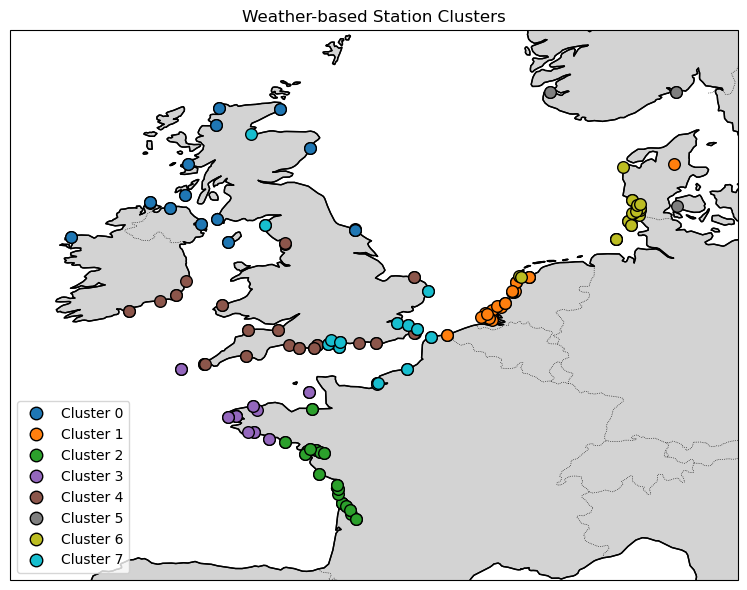

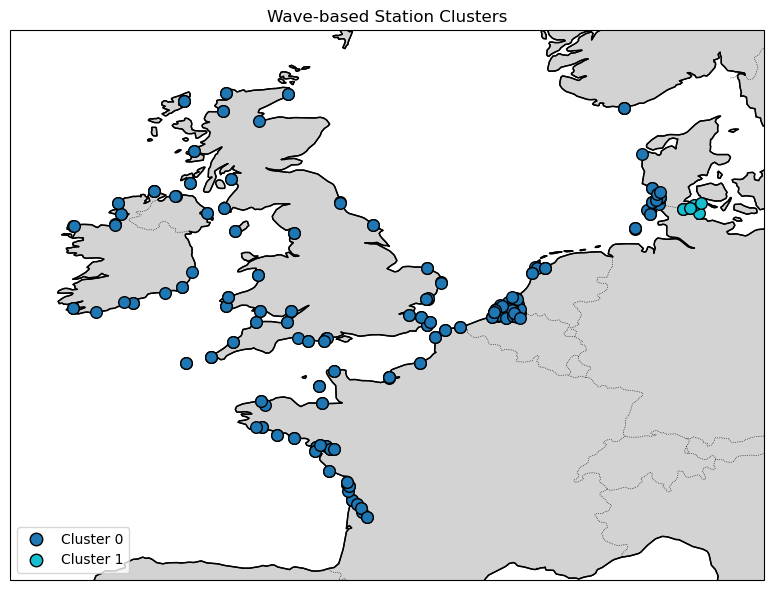

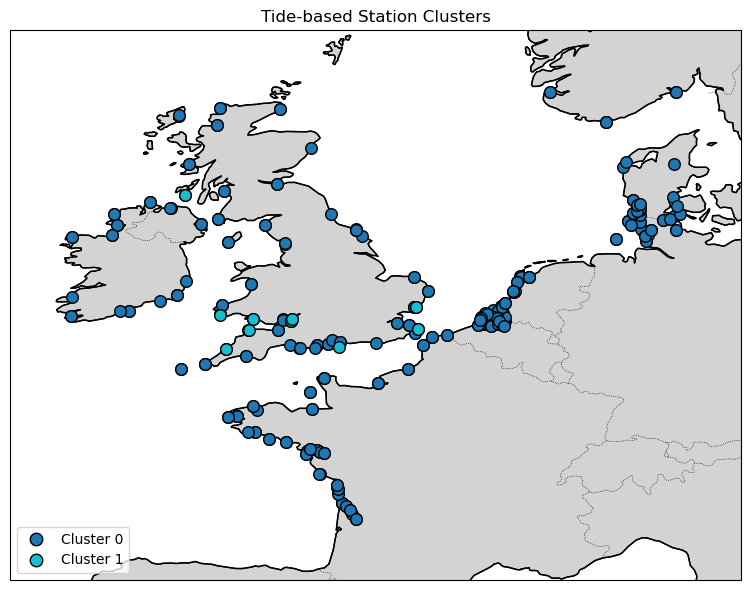

In [ ]:
plot_cluster_map(
    stats_df,
    cluster_col="cluster_weather",
    title="Weather-based Station Clusters",
)

plot_cluster_map(
    stats_df,
    cluster_col="cluster_waves",
    title="Wave-based Station Clusters",
)

plot_cluster_map(
    stats_df,
    cluster_col="cluster_tide",
    title="Tide-based Station Clusters",
)


In [ ]:
print("Weather clusters:")
print(stats_df["cluster_weather"].value_counts(dropna=False))

print("\nWave clusters:")
print(stats_df["cluster_waves"].value_counts(dropna=False))

print("\nTide clusters:")
print(stats_df["cluster_tide"].value_counts(dropna=False))

print(f"Weather: best k = {k_weather}")
print(f"Waves:   best k = {k_waves}")
print(f"Tide:    best k = {k_tide}")



Weather clusters:
cluster_weather
NaN    103
2.0     33
4.0     33
0.0     29
1.0     28
7.0     26
6.0     20
3.0     18
5.0      5
Name: count, dtype: int64

Wave clusters:
cluster_waves
0.0    226
NaN     62
1.0      7
Name: count, dtype: int64

Tide clusters:
cluster_tide
0.0    269
NaN     16
1.0     10
Name: count, dtype: int64
Weather: best k = 8
Waves:   best k = 2
Tide:    best k = 2
